# Olist Review Text Customer-Experience Analysis

**Business question:** What are customers discussing in written reviews, which
named issues dominate low-scored experiences, and what recorded order outcomes
sit behind reported non-receipt?

The analysis uses every order with usable written review text. It preserves all
order statuses, removes only null, blank and case-insensitive duplicate comments
within the same order, and combines genuinely different comments into one
order-level document.

## Analytical flow

1. Prepare one cleaned Portuguese review document per order.
2. discover and freeze parent topics using the complete review corpus;
3. group the technical topics into readable business families;
4. select high-volume, information-rich families using reproducible rules;
5. discover and freeze child topics using all reviews in those families;
6. identify the most common named themes among 1–2-star reviews; and
7. reconcile reported non-receipt with recorded delivery outcomes.

Orders without written text cannot enter topic modelling, but they remain in the
structured orders table for delivery-outcome reconciliation where applicable.

## Reproducibility and saved artifacts

The parent and child model filenames contain both an explicit all-review version
and a corpus signature. A saved model is loaded only when its assignment file
matches the complete current order-level review corpus. A corpus change therefore
creates a new artifact path rather than silently reusing an incompatible model.

In [1]:
# Importing data and visualisation libraries
import hashlib
import json
import os
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import snowflake.connector

In [2]:
# Importing NLP and connection utilities
from bertopic import BERTopic
from cryptography.hazmat.primitives import serialization
from dotenv import load_dotenv
from hdbscan import HDBSCAN
from IPython.display import display
from sentence_transformers import SentenceTransformer
from sklearn.feature_extraction.text import CountVectorizer
from stopwordsiso import stopwords
from tqdm.auto import tqdm
from transformers import MarianMTModel, MarianTokenizer
from umap import UMAP

load_dotenv(override=True)
print("Python environment is ready.")

Python environment is ready.


In [3]:
# Setting reproducible modelling parameters
embedding_model_name = (
    "sentence-transformers/"
    "paraphrase-multilingual-MiniLM-L12-v2"
)
parent_min_topic_size = 100
subtopic_min_size = 30
random_state = 42

parent_model_version = "all_reviews_curated_v1"
subtopic_model_version = "validated_all_reviews_v1"
negative_scores = [1, 2]

In [4]:
# Setting source relations and output folders
orders_relation = os.getenv(
    "OLIST_ORDERS_RELATION",
    "OLIST_DB.DBT_ITANASEKAR_MARTS.FCT_OLIST__ORDERS"
)
reviews_relation = os.getenv(
    "OLIST_REVIEWS_RELATION",
    "OLIST_DB.DBT_ITANASEKAR_MARTS.FCT_OLIST__ORDER_REVIEWS"
)

artifact_dir = Path("outputs/review_text_analysis")
legacy_artifact_dir = Path("outputs/review_text_analysis_legacy")
report_output_dir = Path("outputs/review_text_customer_experience")
artifact_dir.mkdir(parents=True, exist_ok=True)
report_output_dir.mkdir(parents=True, exist_ok=True)

## 1. Load structured orders and every review row

In [5]:
# Connecting to Snowflake using the existing project credentials
key_path = os.getenv("SNOWFLAKE_PRIVATE_KEY_FILE")
passphrase = os.getenv("SNOWFLAKE_PRIVATE_KEY_PASSPHRASE")

if not key_path:
    raise ValueError("SNOWFLAKE_PRIVATE_KEY_FILE is not configured.")

with open(key_path, "rb") as key_file:
    private_key = serialization.load_pem_private_key(
        key_file.read(),
        password=passphrase.encode() if passphrase else None
    )

In [6]:
# Opening the Snowflake connection
conn = snowflake.connector.connect(
    account=os.getenv("SNOWFLAKE_ACCOUNT"),
    user=os.getenv("SNOWFLAKE_USER"),
    authenticator="SNOWFLAKE_JWT",
    private_key=private_key,
    warehouse=os.getenv("SNOWFLAKE_WAREHOUSE"),
    database=os.getenv("SNOWFLAKE_DATABASE"),
    schema=os.getenv("SNOWFLAKE_SCHEMA")
)
print("Connected to Snowflake.")

Connected to Snowflake.


In [7]:
# Loading the structured order fields needed for reconciliation
orders_query = f'''
select
    order_id,
    order_status,
    order_purchase_timestamp,
    order_delivered_customer_date,
    order_estimated_delivery_date,
    is_late_delivery
from {orders_relation}
'''

with conn.cursor() as cursor:
    cursor.execute(orders_query)
    orders_df = cursor.fetch_pandas_all()

orders_df.columns = orders_df.columns.str.lower()

In [8]:
# Converting order timestamps
order_date_columns = [
    "order_purchase_timestamp",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for column in order_date_columns:
    orders_df[column] = pd.to_datetime(
        orders_df[column], errors="coerce"
    )

In [9]:
# Loading every review row without an order-status filter
reviews_query = f'''
select
    review_id,
    order_id,
    satisfaction_score,
    review_text_pt,
    survey_issued_at,
    survey_submitted_at,
    is_latest_review
from {reviews_relation}
'''

with conn.cursor() as cursor:
    cursor.execute(reviews_query)
    reviews_df = cursor.fetch_pandas_all()

reviews_df.columns = reviews_df.columns.str.lower()

In [10]:
# Converting review timestamps and closing the connection
review_date_columns = ["survey_issued_at", "survey_submitted_at"]

for column in review_date_columns:
    reviews_df[column] = pd.to_datetime(
        reviews_df[column], errors="coerce"
    )

conn.close()

In [11]:
# Checking essential source conditions
source_audit = pd.Series({
    "order_rows": len(orders_df),
    "unique_orders": orders_df["order_id"].nunique(),
    "review_rows": len(reviews_df),
    "unique_reviewed_orders": reviews_df["order_id"].nunique(),
    "missing_purchase_timestamps": orders_df[
        "order_purchase_timestamp"
    ].isna().sum()
})

assert orders_df["order_id"].is_unique
assert source_audit["missing_purchase_timestamps"] == 0
display(source_audit)

order_rows                     99441
unique_orders                  99441
review_rows                    99224
unique_reviewed_orders         98673
missing_purchase_timestamps        0
dtype: int64

## 2. Create one cleaned review document per order

Null and blank comments are excluded. Exact duplicate text is removed only
within the same order and genuinely different comments are retained and combined.
All order statuses remain eligible.

In [12]:
# Identifying usable written comments
reviews_df["has_comment"] = (
    reviews_df["review_text_pt"].notna()
    & (reviews_df["review_text_pt"].astype("string").str.strip() != "")
)

written_reviews_df = reviews_df[reviews_df["has_comment"]].copy()
written_reviews_df["review_text_key"] = (
    written_reviews_df["review_text_pt"]
    .astype("string")
    .str.strip()
    .str.casefold()
)

In [13]:
# Removing only case-insensitive exact duplicates within an order
distinct_review_text_df = (
    written_reviews_df
    .sort_values([
        "order_id", "review_text_key",
        "survey_submitted_at", "review_id"
    ])
    .drop_duplicates(
        subset=["order_id", "review_text_key"],
        keep="first"
    )
    .drop(columns="review_text_key")
    .copy()
)

In [14]:
# Combining different comments attached to the same order
def combine_review_text(text_values):
    '''Join non-null review comments while preserving their text.'''
    usable_text = text_values.dropna().astype(str)
    if len(usable_text) > 0:
        return "\n".join(usable_text)
    return pd.NA


general_review_rows_df = distinct_review_text_df.merge(
    orders_df[["order_id", "order_status"]],
    on="order_id", how="left", validate="many_to_one"
)

In [15]:
# Creating one all-status review document per order
general_review_df = (
    general_review_rows_df
    .groupby(
        ["order_id", "order_status"],
        as_index=False, dropna=False
    )
    .agg(
        review_text_pt_general=(
            "review_text_pt", combine_review_text
        ),
        distinct_comment_count=("review_text_pt", "count")
    )
)

assert general_review_df["order_id"].is_unique

In [16]:
# Keeping the latest score without discarding earlier written text
latest_score_df = (
    reviews_df[reviews_df["is_latest_review"].fillna(False)]
    [["order_id", "satisfaction_score"]]
    .rename(columns={
        "satisfaction_score": "latest_satisfaction_score"
    })
    .copy()
)

assert latest_score_df["order_id"].is_unique

In [17]:
# Reporting the order-level review corpus
cleaning_audit = pd.Series({
    "written_rows_before_deduplication": len(written_reviews_df),
    "exact_duplicate_rows_removed": (
        len(written_reviews_df) - len(distinct_review_text_df)
    ),
    "orders_with_usable_text": len(general_review_df),
    "orders_with_multiple_distinct_comments": (
        general_review_df["distinct_comment_count"] > 1
    ).sum(),
    "missing_order_status": general_review_df["order_status"].isna().sum()
})

display(cleaning_audit)

written_rows_before_deduplication         42687
exact_duplicate_rows_removed                 14
orders_with_usable_text                   42540
orders_with_multiple_distinct_comments      132
missing_order_status                          0
dtype: int64

## 3. Discover and freeze parent topics from all cleaned reviews

The corpus below contains every order-level document created in Section 2.
The corpus signature is embedded in the saved filenames, and the saved assignment
file is checked row-for-row before a frozen model is accepted.

In [18]:
# Preparing the complete topic corpus in stable order
general_topic_df = (
    general_review_df[[
        "order_id", "order_status", "review_text_pt_general"
    ]]
    .dropna(subset=["review_text_pt_general"])
    .sort_values("order_id")
    .reset_index(drop=True)
)

general_documents = (
    general_topic_df["review_text_pt_general"]
    .astype(str).tolist()
)

In [19]:
# Creating a stable signature for the complete review corpus
def corpus_signature(ids, texts):
    '''Hash document identifiers and text after stable sorting.'''
    values = sorted(
        f"{order_id}|{text}"
        for order_id, text in zip(ids, texts)
    )
    joined_values = "\n".join(values).encode("utf-8")
    return hashlib.sha256(joined_values).hexdigest()[:12]


general_signature = corpus_signature(
    general_topic_df["order_id"], general_documents
)
print("All-review corpus signature:", general_signature)

All-review corpus signature: 3024bb59c592


In [20]:
# Defining corpus-specific parent-model paths
parent_model_path = artifact_dir / (
    f"parent_topic_model_{parent_model_version}_"
    f"{general_signature}.pickle"
)
parent_assignment_path = artifact_dir / (
    f"parent_topic_assignments_{parent_model_version}_"
    f"{general_signature}.parquet"
)
embedding_path = artifact_dir / (
    f"all_review_embeddings_{general_signature}.npy"
)

legacy_parent_model_path = (
    legacy_artifact_dir / "general_review_topic_model_v1.pickle"
)
legacy_parent_assignment_path = (
    legacy_artifact_dir / "general_review_topic_assignments_v1.parquet"
)

In [21]:
# Resolving a complete parent-model artifact pair
new_parent_flags = [
    parent_model_path.exists(),
    parent_assignment_path.exists()
]
legacy_parent_flags = [
    legacy_parent_model_path.exists(),
    legacy_parent_assignment_path.exists()
]

if any(new_parent_flags) and not all(new_parent_flags):
    raise FileNotFoundError(
        "The new all-review parent artifact pair is incomplete."
    )

use_new_parent_model = all(new_parent_flags)
use_legacy_parent_model = (
    not use_new_parent_model and all(legacy_parent_flags)
)
use_frozen_parent_model = (
    use_new_parent_model or use_legacy_parent_model
)

In [22]:
# Loading the multilingual embedding model
embedding_model = SentenceTransformer(embedding_model_name)

if embedding_path.exists():
    general_embeddings = np.load(embedding_path)
    print("Loaded cached all-review embeddings.")
else:
    general_embeddings = embedding_model.encode(
        general_documents,
        batch_size=32,
        show_progress_bar=True,
        normalize_embeddings=True
    )
    np.save(embedding_path, general_embeddings)
    print("Created all-review embeddings.")

assert len(general_embeddings) == len(general_topic_df)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loaded cached all-review embeddings.


In [23]:
# Configuring reproducible parent-topic discovery
parent_umap_model = UMAP(
    n_neighbors=15,
    n_components=5,
    min_dist=0.0,
    metric="cosine",
    random_state=random_state
)
parent_hdbscan_model = HDBSCAN(
    min_cluster_size=parent_min_topic_size,
    metric="euclidean",
    cluster_selection_method="eom",
    prediction_data=True
)

In [24]:
# Configuring Portuguese topic keywords
parent_vectorizer_model = CountVectorizer(
    stop_words=list(stopwords("pt")),
    ngram_range=(1, 2),
    min_df=5
)

In [25]:
# Loading and validating the frozen all-review parent model
if use_frozen_parent_model:
    selected_model_path = (
        parent_model_path if use_new_parent_model
        else legacy_parent_model_path
    )
    selected_assignment_path = (
        parent_assignment_path if use_new_parent_model
        else legacy_parent_assignment_path
    )
    topic_model = BERTopic.load(selected_model_path)
    frozen_parent_df = pd.read_parquet(selected_assignment_path)

    current_check = general_topic_df[[
        "order_id", "review_text_pt_general"
    ]].reset_index(drop=True)
    frozen_check = frozen_parent_df[[
        "order_id", "review_text_pt_general"
    ]].reset_index(drop=True)

    if not current_check.equals(frozen_check):
        raise ValueError(
            "The available frozen parent assignments do not match "
            "the complete all-review corpus."
        )

In [26]:
# Restoring frozen parent-topic assignments
if use_frozen_parent_model:
    general_topic_df["topic_id"] = (
        frozen_parent_df["topic_id"].astype(int).to_numpy()
    )
    general_topics = general_topic_df["topic_id"].to_numpy()
    if use_legacy_parent_model:
        topic_model.save(parent_model_path, serialization="pickle")
        frozen_parent_df.to_parquet(parent_assignment_path, index=False)
        print("Validated and migrated the all-review parent model.")
    else:
        print("Loaded frozen all-review parent model.")

2026-09-07 22:56:18,322 - BERTopic - WARNING: When you use `pickle` to save/load a BERTopic model,please make sure that the environments in which you saveand load the model are **exactly** the same. The version of BERTopic,its dependencies, and python need to remain the same.


Validated and migrated the all-review parent model.


In [27]:
# Fitting the all-review parent model on its first run
if not use_frozen_parent_model:
    topic_model = BERTopic(
        embedding_model=None,
        umap_model=parent_umap_model,
        hdbscan_model=parent_hdbscan_model,
        vectorizer_model=parent_vectorizer_model,
        calculate_probabilities=False,
        verbose=True
    )
    general_topics, _ = topic_model.fit_transform(
        general_documents, embeddings=general_embeddings
    )
    general_topic_df["topic_id"] = general_topics

In [28]:
# Freezing a newly fitted all-review parent model
if not use_frozen_parent_model:
    topic_model.save(parent_model_path, serialization="pickle")
    general_topic_df[[
        "order_id", "review_text_pt_general", "topic_id"
    ]].to_parquet(parent_assignment_path, index=False)
    print("Fitted and froze the all-review parent model.")

In [29]:
# Verifying that every eligible review order received an assignment
expected_parent_orders = set(
    general_review_df["order_id"].astype(str)
)
assigned_parent_orders = set(
    general_topic_df["order_id"].astype(str)
)

assert assigned_parent_orders == expected_parent_orders
assert general_topic_df["topic_id"].notna().all()

print(
    "Parent assignments validated for",
    f"{len(assigned_parent_orders):,} all-review orders."
)

Parent assignments validated for 42,540 all-review orders.


In [30]:
# Recreating the parent-topic catalogue
topic_info_df = topic_model.get_topic_info()
parent_topic_catalog_df = (
    topic_info_df[["Topic", "Count", "Name"]]
    .rename(columns={
        "Topic": "topic_id",
        "Count": "document_count",
        "Name": "keywords_pt"
    })
    .copy()
)
parent_topic_catalog_df["prevalence_pct"] = (
    parent_topic_catalog_df["document_count"]
    / len(general_topic_df) * 100
)

## 4. Inspect and label the parent topics

In [31]:
# Collecting representative Portuguese comments per parent topic
representative_rows = []

for topic_id in topic_info_df.loc[
    topic_info_df["Topic"] != -1, "Topic"
]:
    keywords = ", ".join(
        word for word, _ in topic_model.get_topic(topic_id)[:8]
    )
    examples = topic_model.get_representative_docs(topic_id)[:3]
    for number, text_pt in enumerate(examples, start=1):
        representative_rows.append({
            "topic_id": int(topic_id),
            "keywords_pt": keywords,
            "example_number": number,
            "review_text_pt": text_pt
        })

representative_topics_df = pd.DataFrame(representative_rows)

In [32]:
# Setting optional representative-example translation
run_representative_translation = False
translation_model_name = "Helsinki-NLP/opus-mt-mul-en"
translation_batch_size = 16
translator_tokenizer = None
translator_model = None

In [33]:
# Loading the translator only when requested
if run_representative_translation:
    translator_tokenizer = MarianTokenizer.from_pretrained(
        translation_model_name
    )
    translator_model = MarianMTModel.from_pretrained(
        translation_model_name
    )

In [34]:
# Translating one manageable batch of representative comments
def translate_batch(texts):
    encoded = translator_tokenizer(
        texts,
        return_tensors="pt",
        padding=True,
        truncation=True,
        max_length=512
    )
    translated = translator_model.generate(**encoded)
    return translator_tokenizer.batch_decode(
        translated, skip_special_tokens=True
    )

In [35]:
# Translating a list in small batches
def translate_texts(texts):
    translations = []
    for start in tqdm(range(0, len(texts), translation_batch_size)):
        batch = texts[start:start + translation_batch_size]
        translations.extend(translate_batch(batch))
    return translations

In [36]:
# Translating parent-topic examples when enabled
if run_representative_translation:
    representative_topics_df["review_text_en"] = translate_texts(
        representative_topics_df["review_text_pt"].tolist()
    )
else:
    representative_topics_df["review_text_en"] = pd.NA

display(representative_topics_df.head(12))

,topic_id,keywords_pt,example_number,review_text_pt,review_text_en
0,0,"recebi, comprei, produto, veio, recebi produto...",1,Até agora não recebi o produto,<NA>
1,0,"recebi, comprei, produto, veio, recebi produto...",2,não recebi não recebi o produto!,<NA>
2,0,"recebi, comprei, produto, veio, recebi produto...",3,Meu produto ainda não fo Ainda não recebi meu ...,<NA>
3,1,"prazo, chegou prazo, chegou, entrega prazo, pr...",1,chegou no prazo,<NA>
4,1,"prazo, chegou prazo, chegou, entrega prazo, pr...",2,Parabéns chegou antes do prazo,<NA>
5,1,"prazo, chegou prazo, chegou, entrega prazo, pr...",3,Chegou antes do prazo!!,<NA>
6,2,"qualidade, produto, recomendo, excelente, gost...",1,"Recomendo, produto de qualidade.",<NA>
7,2,"qualidade, produto, recomendo, excelente, gost...",2,recomendo produto de boa qualidade,<NA>
8,2,"qualidade, produto, recomendo, excelente, gost...",3,SUPER RECOMENDO Produto muito útil e ótima qua...,<NA>
9,3,"chegou prazo, produto chegou, chegou, prazo, p...",1,O produto chegou antes do prazo e em ótimas co...,<NA>


### Curated English labels and business families

The model IDs remain technical keys. These mappings were created by inspecting
keywords and representative comments. If a deliberately new corpus produces
different IDs, review the new examples before changing this dictionary.

In [37]:
# Mapping parent topics to English labels
topic_labels_en = {
    0: "Mixed order, receipt and fulfilment experience",
    1: "Delivered within or before expected timeframe",
    2: "Positive product quality and recommendation",
    3: "Product arrived before expected timeframe",
    4: "Positive store experience and recommendation",
    5: "On-time delivery and product quality",
    6: "Fast delivery",
    7: "Order received as expected",
    8: "Everything correct or as agreed",
    9: "Product appearance and satisfaction",
    10: "Very fast delivery",
    11: "Watch product feedback",
    12: "Lighting product feedback"
}

In [38]:
# Continuing the parent-topic labels
topic_labels_en.update({
    13: "Wrong product colour",
    14: "Strong recommendation",
    15: "Product not yet tested",
    16: "Positive service or company feedback",
    17: "Short generic evaluation",
    18: "Positive product feedback",
    19: "Positive product receipt feedback",
    20: "Positive purchase experience",
    21: "Generic thanks or low-information feedback",
    22: "Positive customer service",
    23: "Generic recommendation",
    24: "Generic excellent feedback",
    25: "Unable to evaluate because product not received"
})

In [39]:
# Continuing the parent-topic labels
topic_labels_en.update({
    26: "Good value for money",
    27: "Fast delivery",
    28: "Generic excellent feedback",
    29: "Curtain product feedback",
    30: "Chair condition and assembly feedback",
    31: "Positive seller feedback",
    32: "Generic great feedback",
    33: "Customer satisfaction",
    34: "Rating of 10 out of 10",
    35: "Generic recommendation",
    36: "Low-information or symbol-only feedback",
    37: "Generic recommendation",
    38: "Product met expectations"
})

In [40]:
# Completing the parent-topic labels
topic_labels_en.update({
    39: "Positive website experience",
    40: "Positive company or customer-service feedback",
    41: "Rating of 10 out of 10",
    42: "Rating of 10 out of 10 and order received"
})

In [41]:
# Grouping parent topics into business families
topic_families_en = {
    -1: "Other / unassigned",
    36: "Other / unassigned",
    0: "Mixed order and fulfilment experience",
    25: "Mixed order and fulfilment experience",
    1: "Delivery timing",
    3: "Delivery timing",
    5: "Delivery timing",
    6: "Delivery timing",
    7: "Delivery timing",
    10: "Delivery timing",
    27: "Delivery timing",
    2: "Product experience",
    9: "Product experience"
}

In [42]:
# Continuing the business-family mapping
topic_families_en.update({
    13: "Product experience",
    15: "Product experience",
    18: "Product experience",
    19: "Product experience",
    26: "Product experience",
    38: "Product experience",
    4: "Store, seller and service experience",
    16: "Store, seller and service experience",
    20: "Store, seller and service experience",
    22: "Store, seller and service experience",
    31: "Store, seller and service experience",
    39: "Store, seller and service experience",
    40: "Store, seller and service experience"
})

In [43]:
# Grouping generic positive topics
generic_positive_topics = [
    8, 14, 17, 21, 23, 24, 28,
    32, 33, 34, 35, 37, 41, 42
]

for topic_id in generic_positive_topics:
    topic_families_en[topic_id] = "Generic positive or confirmation"

for topic_id in [11, 12, 29, 30]:
    topic_families_en[topic_id] = "Product-specific feedback"

In [44]:
# Validating the curated parent-topic mapping
model_topic_ids = set(topic_info_df["Topic"].astype(int))
expected_label_ids = model_topic_ids - {-1}

if set(topic_labels_en) != expected_label_ids:
    missing_ids = expected_label_ids - set(topic_labels_en)
    extra_ids = set(topic_labels_en) - expected_label_ids
    raise ValueError(
        f"Review parent-topic labels. Missing: {sorted(missing_ids)}; "
        f"extra: {sorted(extra_ids)}"
    )

if set(topic_families_en) != model_topic_ids:
    raise ValueError("Review the business-family mapping for the new model.")

In [45]:
# Adding readable parent labels and business families
def get_parent_label(topic_id):
    if topic_id == -1:
        return "Other / unassigned"
    return topic_labels_en[topic_id]


general_topic_df["topic_label_en"] = (
    general_topic_df["topic_id"].map(get_parent_label)
)
general_topic_df["topic_family_en"] = (
    general_topic_df["topic_id"].map(topic_families_en)
)
assert general_topic_df["topic_family_en"].notna().all()

In [46]:
# Completing the readable parent-topic catalogue
parent_topic_catalog_df["topic_label_en"] = (
    parent_topic_catalog_df["topic_id"].map(get_parent_label)
)
parent_topic_catalog_df["topic_family_en"] = (
    parent_topic_catalog_df["topic_id"].map(topic_families_en)
)

display(parent_topic_catalog_df)

,topic_id,document_count,keywords_pt,prevalence_pct,topic_label_en,topic_family_en
0,-1,11282,-1_produto_recomendo_entrega_prazo,26.520921,Other / unassigned,Other / unassigned
1,0,12447,0_recebi_comprei_produto_veio,29.259520,"Mixed order, receipt and fulfilment experience",Mixed order and fulfilment experience
2,1,2599,1_prazo_chegou prazo_chegou_entrega prazo,6.109544,Delivered within or before expected timeframe,Delivery timing
3,2,2023,2_qualidade_produto_recomendo_excelente,4.755524,Positive product quality and recommendation,Product experience
4,3,1392,3_chegou prazo_produto chegou_chegou_prazo,3.272214,Product arrived before expected timeframe,Delivery timing
5,4,1228,4_loja_recomendo loja_lannister_comprar,2.886695,Positive store experience and recommendation,"Store, seller and service experience"
6,5,1128,5_entregue prazo_prazo produto_prazo_produto e...,2.651622,On-time delivery and product quality,Delivery timing
7,6,941,6_rpida_entrega rpida_rpida produto_rpido,2.212036,Fast delivery,Delivery timing
8,7,908,7_recebi_produto_prazo_entregue,2.134462,Order received as expected,Delivery timing
9,8,835,8_certo_combinado_conforme combinado_conforme,1.962858,Everything correct or as agreed,Generic positive or confirmation


## 5. Describe business families across all written reviews

In [47]:
# Attaching the latest recorded score to each order-level document
general_topic_df = general_topic_df.merge(
    latest_score_df,
    on="order_id",
    how="left",
    validate="one_to_one"
)
general_topic_df["is_low_score"] = (
    general_topic_df["latest_satisfaction_score"].isin(negative_scores)
)

In [48]:
# Summarising review volume and low-score incidence by family
topic_family_summary = (
    general_topic_df
    .groupby("topic_family_en", as_index=False)
    .agg(
        written_review_orders=("order_id", "nunique"),
        reviews_with_score=(
            "latest_satisfaction_score", "count"
        ),
        low_score_orders=("is_low_score", "sum")
    )
)
topic_family_summary["low_score_orders"] = (
    topic_family_summary["low_score_orders"].astype(int)
)

In [49]:
# Calculating family prevalence and low-score rate
topic_family_summary["review_prevalence_pct"] = (
    topic_family_summary["written_review_orders"]
    / len(general_topic_df) * 100
)
topic_family_summary["low_score_rate_pct"] = (
    topic_family_summary["low_score_orders"]
    / topic_family_summary["reviews_with_score"] * 100
)
topic_family_summary = topic_family_summary.sort_values(
    "written_review_orders", ascending=False
).reset_index(drop=True)

display(topic_family_summary.round(2))

,topic_family_en,written_review_orders,reviews_with_score,low_score_orders,review_prevalence_pct,low_score_rate_pct
0,Mixed order and fulfilment experience,12647,12647,8343,29.73,65.97
1,Other / unassigned,11408,11408,1396,26.82,12.24
2,Delivery timing,7664,7664,438,18.02,5.72
3,Product experience,4183,4183,323,9.83,7.72
4,Generic positive or confirmation,3158,3158,77,7.42,2.44
5,"Store, seller and service experience",2343,2343,61,5.51,2.60
6,Product-specific feedback,1137,1137,309,2.67,27.18


<BarContainer object of 7 artists>

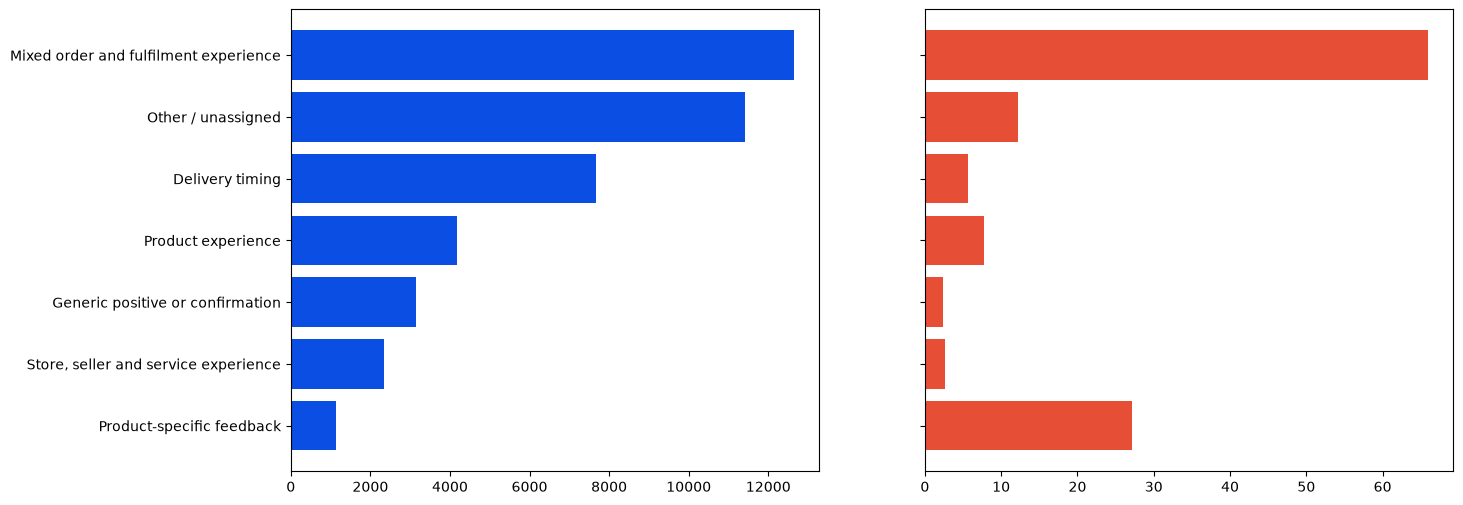

In [50]:
# Comparing review coverage and low-score rate by family
family_plot_df = topic_family_summary.sort_values(
    "written_review_orders"
)
fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharey=True)

axes[0].barh(
    family_plot_df["topic_family_en"],
    family_plot_df["written_review_orders"],
    color="#0A4EE4"
)
axes[1].barh(
    family_plot_df["topic_family_en"],
    family_plot_df["low_score_rate_pct"],
    color="#E64E36"
)

In [51]:
# Formatting the family-level overview
axes[0].set_title("Written-review orders")
axes[1].set_title("Share scored 1–2 stars")
axes[0].set_xlabel("Unique orders")
axes[1].set_xlabel("Low-score rate (%)")
axes[0].set_ylabel("")
axes[1].set_ylabel("")

for axis in axes:
    axis.grid(axis="x", alpha=0.2)

axes[0].bar_label(
    axes[0].containers[0],
    labels=[f"{value:,}" for value in family_plot_df["written_review_orders"]],
    padding=4
)
axes[1].bar_label(
    axes[1].containers[0],
    labels=[f"{value:.1f}%" for value in family_plot_df["low_score_rate_pct"]],
    padding=4
)
axes[0].set_xlim(0, family_plot_df["written_review_orders"].max() * 1.18)
axes[1].set_xlim(0, family_plot_df["low_score_rate_pct"].max() * 1.18)

fig.suptitle("Review Coverage and Dissatisfaction by Business Family")
plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>

## 6. Select business families using all-review evidence

Selection uses only prevalence, text richness and overall written-review volume.
The parent-level unassigned family is retained in coverage reporting but excluded
from child-topic discovery because it is not a coherent business theme.

In [52]:
# Setting transparent family-selection rules
max_selected_families = 3
min_review_prevalence_pct = 2.0
min_informative_words = 4
min_informative_share_pct = 30.0

In [53]:
# Measuring the information contained in each review
family_text_df = general_topic_df[[
    "topic_family_en", "review_text_pt_general"
]].copy()
family_text_df["word_count"] = (
    family_text_df["review_text_pt_general"]
    .astype(str).str.split().str.len()
)
family_text_df["is_informative"] = (
    family_text_df["word_count"] >= min_informative_words
)

In [54]:
# Summarising text richness within each family
family_text_quality_df = (
    family_text_df
    .groupby("topic_family_en", as_index=False)
    .agg(
        median_word_count=("word_count", "median"),
        informative_share=("is_informative", "mean")
    )
)
family_text_quality_df["informative_share_pct"] = (
    family_text_quality_df["informative_share"] * 100
)

In [55]:
# Applying all-review coverage and richness rules
family_selection_audit = topic_family_summary.merge(
    family_text_quality_df[[
        "topic_family_en", "median_word_count",
        "informative_share_pct"
    ]],
    on="topic_family_en",
    how="left",
    validate="one_to_one"
)
family_selection_audit["passes_rules"] = (
    (family_selection_audit["topic_family_en"] != "Other / unassigned")
    & (family_selection_audit["review_prevalence_pct"] >= min_review_prevalence_pct)
    & (family_selection_audit["informative_share_pct"] >= min_informative_share_pct)
)

In [56]:
# Ranking eligible families by complete-corpus review volume
eligible_families = (
    family_selection_audit[family_selection_audit["passes_rules"]]
    [["topic_family_en", "written_review_orders"]]
    .sort_values("written_review_orders", ascending=False)
    .reset_index(drop=True)
)
eligible_families["selection_rank"] = eligible_families.index + 1

family_selection_audit = family_selection_audit.merge(
    eligible_families[["topic_family_en", "selection_rank"]],
    on="topic_family_en", how="left", validate="one_to_one"
)

In [57]:
# Selecting the highest-volume eligible families
family_selection_audit["selected_for_subtopics"] = (
    family_selection_audit["selection_rank"] <= max_selected_families
).fillna(False)

selected_topic_families = (
    family_selection_audit[
        family_selection_audit["selected_for_subtopics"]
    ]
    .sort_values("selection_rank")
    ["topic_family_en"].tolist()
)

if not selected_topic_families:
    raise ValueError("No business families passed the selection rules.")

print("Rule-selected families:", selected_topic_families)

Rule-selected families: ['Mixed order and fulfilment experience', 'Delivery timing', 'Product experience']


In [58]:
# Recording the reason for each selected family
topic_family_selection_decisions = (
    family_selection_audit[
        family_selection_audit["selected_for_subtopics"]
    ]
    .sort_values("selection_rank")
    .copy()
)
topic_family_selection_decisions["analysis_role"] = (
    "All-review family selected for child-topic discovery"
)
topic_family_selection_decisions["selection_reason"] = (
    "Passed prevalence and text-richness rules; "
    "ranked among the highest-volume eligible families."
)

In [59]:
# Displaying the complete family-selection audit
selection_columns = [
    "topic_family_en", "written_review_orders",
    "review_prevalence_pct", "low_score_orders",
    "low_score_rate_pct", "median_word_count",
    "informative_share_pct", "passes_rules",
    "selection_rank", "selected_for_subtopics"
]

display(
    family_selection_audit[selection_columns]
    .sort_values(
        ["selected_for_subtopics", "written_review_orders"],
        ascending=[False, False]
    ).round(2)
)

,topic_family_en,written_review_orders,review_prevalence_pct,low_score_orders,low_score_rate_pct,median_word_count,informative_share_pct,passes_rules,selection_rank,selected_for_subtopics
0,Mixed order and fulfilment experience,12647,29.73,8343,65.97,17.0,98.39,True,1.0,True
2,Delivery timing,7664,18.02,438,5.72,8.0,95.33,True,2.0,True
3,Product experience,4183,9.83,323,7.72,6.0,77.58,True,3.0,True
1,Other / unassigned,11408,26.82,1396,12.24,7.0,67.84,False,NaN,False
4,Generic positive or confirmation,3158,7.42,77,2.44,2.0,20.65,False,NaN,False
5,"Store, seller and service experience",2343,5.51,61,2.60,8.0,83.95,True,4.0,False
6,Product-specific feedback,1137,2.67,309,27.18,10.0,65.08,True,5.0,False


### Validate the selected families

A small random sample is drawn from all comments in each selected family. This
checks whether the business labels remain coherent before child-topic results are
interpreted.

In [60]:
# Sampling all-review comments from each selected family
family_validation_sample_size = 10
family_validation_frames = []

for position, family in enumerate(selected_topic_families):
    validation_pool = general_topic_df[
        general_topic_df["topic_family_en"] == family
    ]
    sample_size = min(family_validation_sample_size, len(validation_pool))
    family_validation_frames.append(
        validation_pool.sample(
            n=sample_size,
            random_state=random_state + position
        )
    )

In [61]:
# Combining and optionally translating the validation sample
family_validation_df = pd.concat(
    family_validation_frames, ignore_index=True
)

if run_representative_translation:
    family_validation_df["review_text_en"] = translate_texts(
        family_validation_df["review_text_pt_general"]
        .astype(str).tolist()
    )
else:
    family_validation_df["review_text_en"] = pd.NA

In [62]:
# Displaying the selected-family validation sample
validation_columns = [
    "topic_id", "topic_label_en", "topic_family_en",
    "latest_satisfaction_score", "review_text_pt_general",
    "review_text_en"
]

with pd.option_context(
    "display.max_rows", None,
    "display.max_colwidth", 100
):
    display(
        family_validation_df[validation_columns]
        .sort_values(["topic_family_en", "topic_id"])
        .reset_index(drop=True)
    )

,topic_id,topic_label_en,topic_family_en,latest_satisfaction_score,review_text_pt_general,review_text_en
0,1,Delivered within or before expected timeframe,Delivery timing,5,Entrega feita em menos de uma semana; Produto ótimo ; Muito bom!,<NA>
1,1,Delivered within or before expected timeframe,Delivery timing,5,Muito bom Recebi bem rapido antes do prazo,<NA>
2,1,Delivered within or before expected timeframe,Delivery timing,3,Recomendado Entrega dentro do prazo previsto. Satisfeito.,<NA>
3,3,Product arrived before expected timeframe,Delivery timing,5,"Entrega antes do prazo, adorei meu produto,perfeito..",<NA>
4,3,Product arrived before expected timeframe,Delivery timing,5,"Capa de chuva/sapato Excelente, ficou linda no meu Boris, super indico. Mercadoria de ótima qual...",<NA>
5,5,On-time delivery and product quality,Delivery timing,5,produto entregue dentro do prazo e com ótima qualidade.,<NA>
6,6,Fast delivery,Delivery timing,5,Muito rápido a entrega e produto bem embalado.,<NA>
7,7,Order received as expected,Delivery timing,5,GOSTEI MUITO DO PRODUTO COMPRADO . BONITO E LEVE PARA ESSA ONDA DE CALOR. SÓ NÃO GOSTEI PORQUE C...,<NA>
8,7,Order received as expected,Delivery timing,5,"EXCELENTE PRODUTO, ATENDIMENTO E ENTREGA ANTES DO PRAZO.",<NA>
9,7,Order received as expected,Delivery timing,1,NÃO RECEBI O PRODUTO,<NA>


## 7. Discover and freeze child topics from all selected-family reviews

Each child model is fitted only to the complete set of order-level review
documents in its parent family. No customer-outcome cohort is created or loaded.

In [63]:
# Creating corpus-specific child-model paths
subtopic_dir = artifact_dir / (
    f"subtopics_{subtopic_model_version}_{general_signature}"
)
subtopic_dir.mkdir(parents=True, exist_ok=True)

subtopic_assignment_path = (
    subtopic_dir / "all_review_subtopic_assignments.parquet"
)
subtopic_examples_path = (
    subtopic_dir / "all_review_subtopic_examples.csv"
)
subtopic_manifest_path = subtopic_dir / "manifest.json"

legacy_subtopic_assignment_path = (
    legacy_artifact_dir / "general_subtopic_assignments.parquet"
)
legacy_subtopic_examples_path = (
    legacy_artifact_dir / "subtopic_representative_examples.csv"
)

In [64]:
# Resolving complete child-topic artifacts
new_subtopic_flags = [
    subtopic_assignment_path.exists(),
    subtopic_examples_path.exists(),
    subtopic_manifest_path.exists()
]
legacy_subtopic_flags = [
    legacy_subtopic_assignment_path.exists(),
    legacy_subtopic_examples_path.exists()
]

if any(new_subtopic_flags) and not all(new_subtopic_flags):
    raise FileNotFoundError(
        "The all-review child-topic artifact set is incomplete."
    )

use_new_subtopics = all(new_subtopic_flags)
use_legacy_subtopics = (
    not use_new_subtopics and all(legacy_subtopic_flags)
)
use_frozen_subtopics = use_new_subtopics or use_legacy_subtopics

In [65]:
# Creating reproducible child-model components
def create_child_components(document_count):
    child_min_size = min(
        subtopic_min_size,
        max(10, document_count // 10)
    )
    child_umap = UMAP(
        n_neighbors=min(15, document_count - 1),
        n_components=5,
        min_dist=0.0,
        metric="cosine",
        random_state=random_state
    )
    child_clusterer = HDBSCAN(
        min_cluster_size=child_min_size,
        metric="euclidean",
        cluster_selection_method="eom",
        prediction_data=True
    )
    child_vectorizer = CountVectorizer(
        stop_words=list(stopwords("pt")),
        ngram_range=(1, 2),
        min_df=1,
        max_df=1.0
    )
    return child_umap, child_clusterer, child_vectorizer

In [66]:
# Building one child model inside a selected family
def build_subtopic_model(family_documents, family_embeddings):
    components = create_child_components(len(family_documents))
    child_umap, child_clusterer, child_vectorizer = components

    child_model = BERTopic(
        embedding_model=None,
        umap_model=child_umap,
        hdbscan_model=child_clusterer,
        vectorizer_model=child_vectorizer,
        calculate_probabilities=False,
        verbose=False
    )
    child_topics, _ = child_model.fit_transform(
        family_documents, embeddings=family_embeddings
    )
    return child_model, child_topics

In [67]:
# Collecting representative comments for every child topic
def collect_subtopic_examples(child_model, parent_family):
    rows = []
    child_info = child_model.get_topic_info()
    topic_ids = child_info.loc[
        child_info["Topic"] != -1, "Topic"
    ]

    for subtopic_id in topic_ids:
        keywords = ", ".join(
            word for word, _ in child_model.get_topic(subtopic_id)[:8]
        )
        examples = child_model.get_representative_docs(subtopic_id)[:3]
        for number, text_pt in enumerate(examples, start=1):
            rows.append({
                "parent_topic_family": parent_family,
                "subtopic_id": int(subtopic_id),
                "keywords_pt": keywords,
                "example_number": number,
                "review_text_pt": text_pt
            })
    return rows

In [68]:
# Preparing containers for newly discovered all-review subtopics
general_subtopic_frames = []
subtopic_representative_rows = []

In [69]:
# Fitting child topics sequentially to limit memory use
if not use_frozen_subtopics:
    for family in selected_topic_families:
        family_mask = (
            general_topic_df["topic_family_en"] == family
        ).to_numpy()
        family_documents = general_topic_df.loc[
            family_mask, "review_text_pt_general"
        ].astype(str).tolist()

        if len(family_documents) < 40:
            raise ValueError(f"Too few documents for {family}.")

        child_model, child_topics = build_subtopic_model(
            family_documents,
            general_embeddings[family_mask]
        )
        safe_name = re.sub(r"[^a-z0-9]+", "_", family.lower()).strip("_")
        child_model.save(
            subtopic_dir / f"{safe_name}_model.pickle",
            serialization="pickle"
        )
        child_df = general_topic_df.loc[
            family_mask, ["order_id"]
        ].copy()
        child_df["parent_topic_family"] = family
        child_df["subtopic_id"] = child_topics
        general_subtopic_frames.append(child_df)
        subtopic_representative_rows.extend(
            collect_subtopic_examples(child_model, family)
        )
        del child_model

In [70]:
# Combining and freezing new all-review child-topic artifacts
if not use_frozen_subtopics:
    general_subtopic_df = pd.concat(
        general_subtopic_frames, ignore_index=True
    )
    subtopic_representatives_df = pd.DataFrame(
        subtopic_representative_rows
    )
    general_subtopic_df.to_parquet(
        subtopic_assignment_path, index=False
    )
    subtopic_representatives_df.to_csv(
        subtopic_examples_path, index=False
    )

In [71]:
# Saving the all-review child-topic manifest
if not use_frozen_subtopics:
    subtopic_manifest = {
        "corpus_signature": general_signature,
        "selected_topic_families": selected_topic_families,
        "order_count": len(general_subtopic_df),
        "model_version": subtopic_model_version
    }
    with open(subtopic_manifest_path, "w", encoding="utf-8") as file:
        json.dump(subtopic_manifest, file, indent=2)
    print("Fitted and froze all-review child-topic models.")

In [72]:
# Loading frozen all-review child-topic artifacts
if use_frozen_subtopics:
    selected_subtopic_assignment_path = (
        subtopic_assignment_path if use_new_subtopics
        else legacy_subtopic_assignment_path
    )
    selected_subtopic_examples_path = (
        subtopic_examples_path if use_new_subtopics
        else legacy_subtopic_examples_path
    )
    general_subtopic_df = pd.read_parquet(
        selected_subtopic_assignment_path
    )
    subtopic_representatives_df = pd.read_csv(
        selected_subtopic_examples_path
    )

    if use_new_subtopics:
        with open(subtopic_manifest_path, encoding="utf-8") as file:
            subtopic_manifest = json.load(file)
        if subtopic_manifest["corpus_signature"] != general_signature:
            raise ValueError("Child-topic manifest does not match the corpus.")
        if subtopic_manifest["selected_topic_families"] != selected_topic_families:
            raise ValueError("Child-topic families do not match current selection.")

In [73]:
# Validating complete selected-family coverage
expected_subtopic_orders = set(
    general_topic_df.loc[
        general_topic_df["topic_family_en"].isin(selected_topic_families),
        "order_id"
    ].astype(str)
)
accepted_subtopic_orders = set(
    general_subtopic_df["order_id"].astype(str)
)

assert general_subtopic_df["order_id"].notna().all()
assert general_subtopic_df["order_id"].is_unique
assert accepted_subtopic_orders == expected_subtopic_orders

if use_legacy_subtopics:
    general_subtopic_df.to_parquet(
        subtopic_assignment_path, index=False
    )
    subtopic_representatives_df.to_csv(
        subtopic_examples_path, index=False
    )
    subtopic_manifest = {
        "corpus_signature": general_signature,
        "selected_topic_families": selected_topic_families,
        "order_count": len(general_subtopic_df),
        "model_version": subtopic_model_version,
        "source": "validated all-review legacy assignments"
    }
    with open(subtopic_manifest_path, "w", encoding="utf-8") as file:
        json.dump(subtopic_manifest, file, indent=2)

print(
    "Child assignments validated for",
    f"{len(accepted_subtopic_orders):,} all-review orders."
)

Child assignments validated for 24,494 all-review orders.


### Consolidate child topics into readable business subtopics

In [74]:
# Building the curated child-topic mapping
subtopic_labels_en = {}


def register_subtopics(parent_family, topic_ids, label):
    '''Assign one business label to one or more child topics.'''
    for topic_id in topic_ids:
        subtopic_labels_en[(parent_family, topic_id)] = label

In [75]:
# Consolidating delivery-timing subtopics
delivery_family = "Delivery timing"

register_subtopics(
    delivery_family, [0, 1, 2],
    "Delivered on or before expected date"
)
register_subtopics(
    delivery_family, [3],
    "Product receipt or mixed delivery feedback"
)
register_subtopics(
    delivery_family, [4, 5, 6, 7, 8, 9],
    "Fast delivery with positive feedback"
)

In [76]:
# Consolidating mixed fulfilment subtopics
mixed_family = "Mixed order and fulfilment experience"

register_subtopics(
    mixed_family, [0, 41],
    "Seller/store service or communication"
)
register_subtopics(
    mixed_family, [1, 7, 22, 34, 42],
    "Late or slow delivery"
)
register_subtopics(
    mixed_family, [9],
    "Delivery timing with mixed sentiment"
)

In [77]:
# Continuing mixed fulfilment subtopics
register_subtopics(
    mixed_family, [2],
    "Postal delivery or collection issue"
)
register_subtopics(
    mixed_family, [3, 11, 31, 43],
    "Cancellation, refund or payment issue"
)
register_subtopics(
    mixed_family, [4, 6, 12, 13, 28, 32, 36],
    "Non-receipt reported at review time"
)
register_subtopics(
    mixed_family, [35, 39],
    "Not yet evaluated or uncertain receipt"
)

In [78]:
# Continuing mixed fulfilment subtopics
register_subtopics(
    mixed_family, [10, 21, 24, 25, 30, 37, 45, 47],
    "Incomplete order or missing item"
)
register_subtopics(
    mixed_family, [5, 8, 15, 17, 18, 40, 44, 48],
    "Wrong, incompatible or mismatched product"
)
register_subtopics(
    mixed_family, [14, 19, 20, 23, 27, 29, 33, 38, 46],
    "Product quality, defect or damage"
)

In [79]:
# Completing mixed fulfilment subtopics
register_subtopics(
    mixed_family, [16],
    "Positive or mixed product feedback"
)
register_subtopics(
    mixed_family, [26],
    "Tax invoice or documentation issue"
)

In [80]:
# Consolidating product-experience subtopics
product_family = "Product experience"

register_subtopics(
    product_family, [0],
    "Positive product quality and recommendation"
)
register_subtopics(
    product_family, [1],
    "Wrong product colour"
)
register_subtopics(
    product_family, [2],
    "Liked or loved the product"
)

In [81]:
# Continuing product-experience subtopics
register_subtopics(
    product_family, [3],
    "Product not yet tested"
)
register_subtopics(
    product_family, [4],
    "Everything correct or recommended"
)
register_subtopics(
    product_family, [5],
    "Good value for money"
)
register_subtopics(
    product_family, [6],
    "Positive product appearance"
)

In [82]:
# Completing product-experience subtopics
register_subtopics(
    product_family, [7],
    "Product met expectations"
)
register_subtopics(
    product_family, [8],
    "Product received correctly or mixed feedback"
)
register_subtopics(
    product_family, [9],
    "Non-receipt reported at review time"
)
register_subtopics(
    product_family, [10, 11, 12, 13],
    "Generic or low-information feedback"
)

In [83]:
# Validating and applying the curated child-topic labels
assigned_subtopics = general_subtopic_df[
    general_subtopic_df["subtopic_id"] != -1
]
discovered_keys = set(zip(
    assigned_subtopics["parent_topic_family"],
    assigned_subtopics["subtopic_id"]
))
missing_keys = discovered_keys - set(subtopic_labels_en)

if missing_keys:
    raise ValueError(
        "Review new all-review child topics before continuing: "
        f"{sorted(missing_keys)}"
    )

In [84]:
# Returning a readable label for every child assignment
def get_subtopic_label(parent_family, subtopic_id):
    if subtopic_id == -1:
        return "Other / unassigned within family"
    return subtopic_labels_en[(parent_family, subtopic_id)]


general_subtopic_df["subtopic_label_en"] = [
    get_subtopic_label(family, subtopic_id)
    for family, subtopic_id in zip(
        general_subtopic_df["parent_topic_family"],
        general_subtopic_df["subtopic_id"]
    )
]

In [85]:
# Adding labels to representative child-topic examples
subtopic_representatives_df["subtopic_label_en"] = [
    get_subtopic_label(family, subtopic_id)
    for family, subtopic_id in zip(
        subtopic_representatives_df["parent_topic_family"],
        subtopic_representatives_df["subtopic_id"]
    )
]

if "review_text_en" not in subtopic_representatives_df.columns:
    subtopic_representatives_df["review_text_en"] = pd.NA

In [86]:
# Counting all-review orders within each consolidated subtopic
subtopic_count_summary = (
    general_subtopic_df
    .groupby(
        ["parent_topic_family", "subtopic_label_en"],
        as_index=False
    )
    .agg(order_count=("order_id", "nunique"))
)
family_totals = subtopic_count_summary.groupby(
    "parent_topic_family"
)["order_count"].transform("sum")
subtopic_count_summary["share_within_family_pct"] = (
    subtopic_count_summary["order_count"] / family_totals * 100
)

In [87]:
# Displaying all consolidated all-review subtopics
subtopic_count_summary = subtopic_count_summary.sort_values(
    ["parent_topic_family", "order_count"],
    ascending=[True, False]
).reset_index(drop=True)

display(subtopic_count_summary.round(2))

,parent_topic_family,subtopic_label_en,order_count,share_within_family_pct
0,Delivery timing,Delivered on or before expected date,5122,66.83
1,Delivery timing,Fast delivery with positive feedback,1498,19.55
2,Delivery timing,Product receipt or mixed delivery feedback,910,11.87
3,Delivery timing,Other / unassigned within family,134,1.75
4,Mixed order and fulfilment experience,Other / unassigned within family,6610,52.27
5,Mixed order and fulfilment experience,Non-receipt reported at review time,970,7.67
6,Mixed order and fulfilment experience,"Wrong, incompatible or mismatched product",904,7.15
7,Mixed order and fulfilment experience,Late or slow delivery,780,6.17
8,Mixed order and fulfilment experience,"Product quality, defect or damage",770,6.09
9,Mixed order and fulfilment experience,Incomplete order or missing item,660,5.22


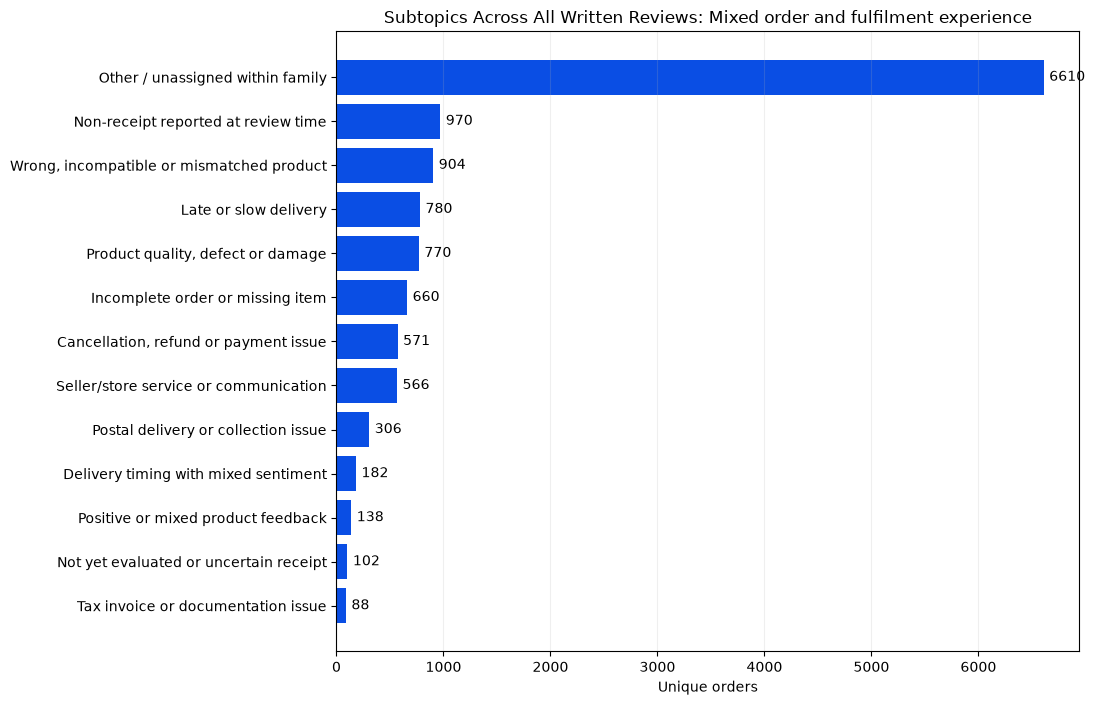

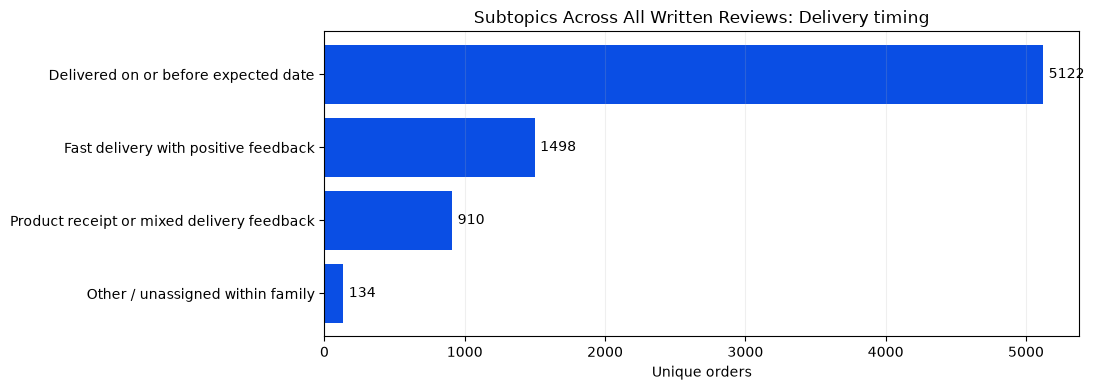

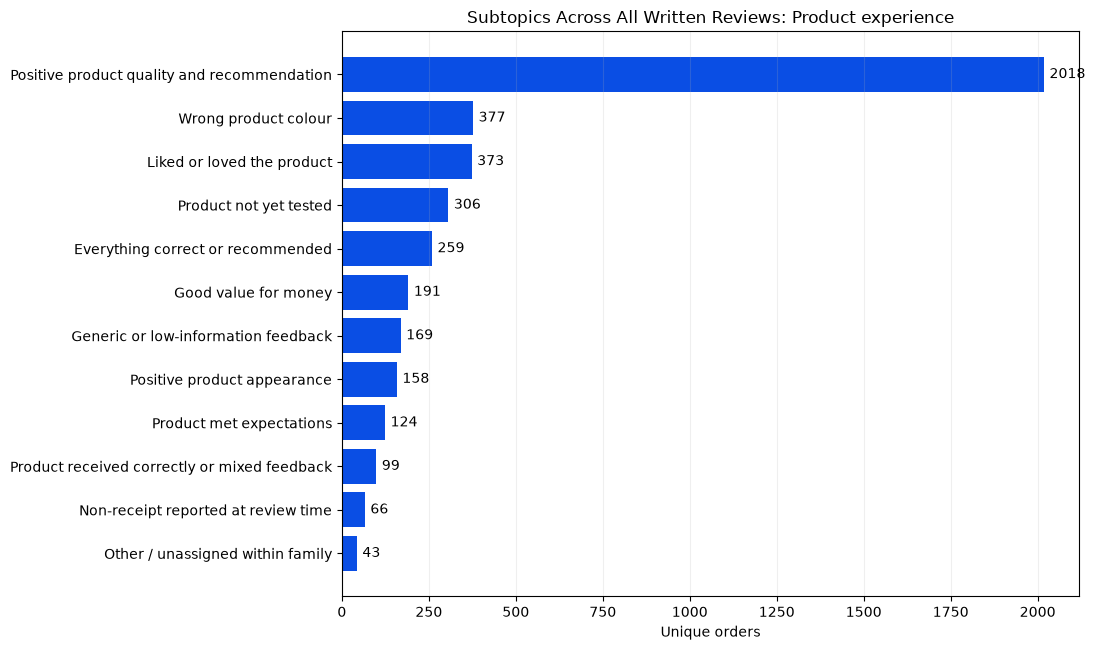

In [88]:
# Plotting all-review subtopic counts within each family
for family in selected_topic_families:
    plot_df = subtopic_count_summary[
        subtopic_count_summary["parent_topic_family"] == family
    ].sort_values("order_count")

    figure_height = max(4, len(plot_df) * 0.55)
    fig, ax = plt.subplots(figsize=(11, figure_height))
    bars = ax.barh(
        plot_df["subtopic_label_en"],
        plot_df["order_count"],
        color="#0A4EE4"
    )
    ax.bar_label(bars, padding=4)
    ax.set_title(f"Subtopics Across All Written Reviews: {family}")
    ax.set_xlabel("Unique orders")
    ax.set_ylabel("")
    ax.grid(axis="x", alpha=0.2)
    plt.tight_layout()
    plt.show()

## 8. Identify the main named themes among low-scored reviews

A negative review is defined as the latest recorded satisfaction score of 1 or 2.
The chart includes every named child theme within the selected families. The
unassigned residual is reported separately as a coverage limitation.

In [89]:
# Connecting all-review child assignments to latest scores
negative_review_subtopics_df = (
    general_subtopic_df.loc[
        general_subtopic_df["subtopic_label_en"]
        != "Other / unassigned within family"
    ]
    .merge(
        latest_score_df,
        on="order_id",
        how="left",
        validate="one_to_one"
    )
)
negative_review_subtopics_df = negative_review_subtopics_df[
    negative_review_subtopics_df[
        "latest_satisfaction_score"
    ].isin(negative_scores)
].copy()

In [90]:
# Counting every named theme among 1–2-star reviews
negative_subtopic_summary = (
    negative_review_subtopics_df
    .groupby("subtopic_label_en", as_index=False)
    .agg(unique_orders=("order_id", "nunique"))
    .sort_values("unique_orders", ascending=False)
    .reset_index(drop=True)
)
negative_subtopic_summary["share_pct"] = (
    negative_subtopic_summary["unique_orders"]
    / negative_subtopic_summary["unique_orders"].sum() * 100
)

display(negative_subtopic_summary.round(2))

,subtopic_label_en,unique_orders,share_pct
0,Non-receipt reported at review time,848,18.23
1,"Wrong, incompatible or mismatched product",522,11.22
2,Late or slow delivery,506,10.88
3,"Cancellation, refund or payment issue",471,10.13
4,Incomplete order or missing item,451,9.70
5,Seller/store service or communication,450,9.68
6,"Product quality, defect or damage",362,7.78
7,Product receipt or mixed delivery feedback,360,7.74
8,Wrong product colour,184,3.96
9,Postal delivery or collection issue,133,2.86


In [91]:
# Preparing a concise management-level view
top_theme_count = 12
negative_theme_plot_df = negative_subtopic_summary.head(
    top_theme_count
).copy()
remaining_count = negative_subtopic_summary.iloc[
    top_theme_count:
]["unique_orders"].sum()

if remaining_count > 0:
    remaining_row = pd.DataFrame({
        "subtopic_label_en": ["Remaining named themes"],
        "unique_orders": [remaining_count]
    })
    negative_theme_plot_df = pd.concat(
        [negative_theme_plot_df, remaining_row], ignore_index=True
    )

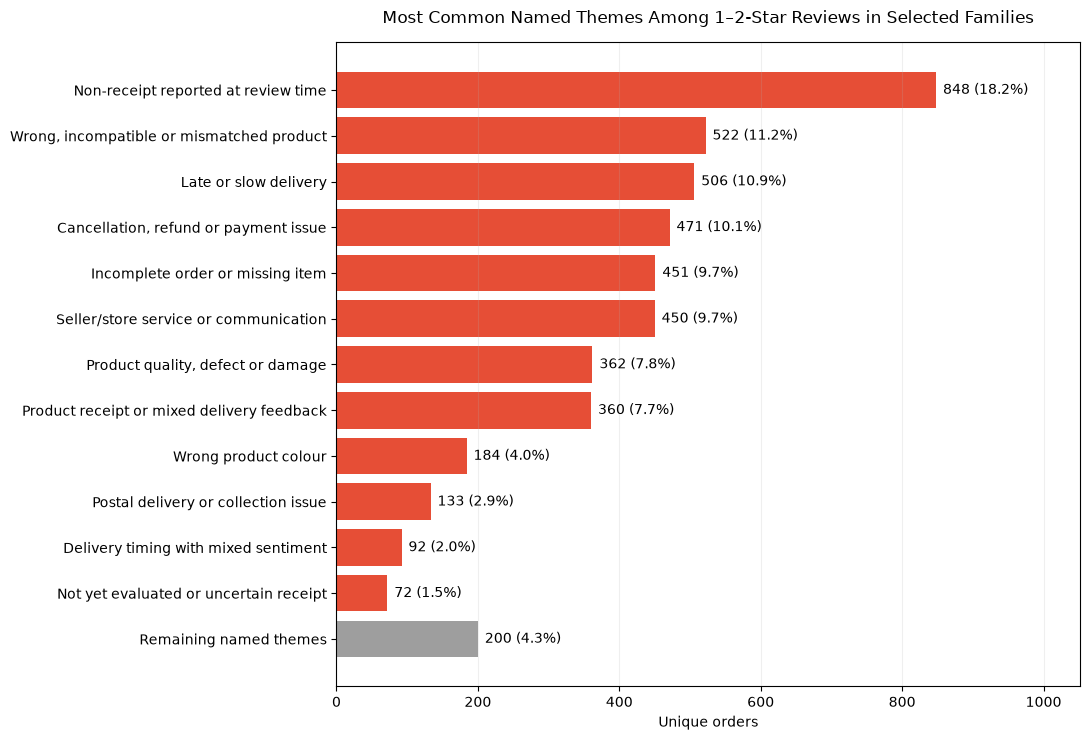

In [110]:
# Calculating displayed shares and plotting the negative themes
total_negative_orders = negative_subtopic_summary[
    "unique_orders"
].sum()
negative_theme_plot_df["share_pct"] = (
    negative_theme_plot_df["unique_orders"]
    / total_negative_orders * 100
)
negative_theme_plot_df = negative_theme_plot_df.iloc[::-1].copy()

bar_colors = [
    "#9E9E9E" if label == "Remaining named themes" else "#E64E36"
    for label in negative_theme_plot_df["subtopic_label_en"]
]
fig, ax = plt.subplots(figsize=(11, 7.5))
bars = ax.barh(
    negative_theme_plot_df["subtopic_label_en"],
    negative_theme_plot_df["unique_orders"],
    color=bar_colors
)

bar_labels = [
    f"{count:,} ({share:.1f}%)"
    for count, share in zip(
        negative_theme_plot_df["unique_orders"],
        negative_theme_plot_df["share_pct"]
    )
]
ax.bar_label(bars, labels=bar_labels, padding=5)
ax.set_title(
    "Most Common Named Themes Among 1–2-Star Reviews "
    "in Selected Families",
    pad=14
)
ax.set_xlabel("Unique orders")
ax.set_ylabel("")
ax.set_xlim(
    0, negative_theme_plot_df["unique_orders"].max() * 1.24
)
ax.grid(axis="x", alpha=0.2)
plt.tight_layout()
plt.show()

## 9. Drill down into reported non-receipt outcomes

The customer statement describes what was known at review time. Structured order
timestamps are therefore used to distinguish eventual late delivery, missing
delivery records, cancelled or unavailable orders, and recorded-delivery
discrepancies.

In [94]:
# Selecting every named non-receipt report across selected families
non_receipt_orders_df = (
    general_subtopic_df.loc[
        general_subtopic_df["subtopic_label_en"]
        == "Non-receipt reported at review time",
        ["order_id"]
    ]
    .drop_duplicates()
    .copy()
)

print("Named non-receipt reports:", len(non_receipt_orders_df))

Named non-receipt reports: 1036


In [95]:
# Preparing the timing of distinct written comments
review_timing_df = (
    distinct_review_text_df
    .groupby("order_id", as_index=False)
    .agg(
        survey_issued_at=("survey_issued_at", "min"),
        review_submitted_at=("survey_submitted_at", "min"),
        distinct_comment_count=("review_id", "size")
    )
)

In [96]:
# Connecting non-receipt reports to recorded delivery outcomes
non_receipt_audit_df = (
    non_receipt_orders_df
    .merge(
        review_timing_df,
        on="order_id", how="left", validate="one_to_one"
    )
    .merge(
        orders_df[[
            "order_id", "order_status",
            "order_delivered_customer_date",
            "order_estimated_delivery_date"
        ]],
        on="order_id", how="left", validate="one_to_one"
    )
)

In [97]:
# Defining mutually exclusive recorded outcomes
submitted = non_receipt_audit_df["review_submitted_at"]
delivered = non_receipt_audit_df["order_delivered_customer_date"]
estimated = non_receipt_audit_df["order_estimated_delivery_date"]
status = non_receipt_audit_df["order_status"]

conditions = [
    submitted.isna(),
    non_receipt_audit_df["distinct_comment_count"] > 1,
    delivered.isna() & status.isin(["canceled", "unavailable"]),
    delivered.isna(),
    (submitted < delivered) & (delivered > estimated),
    (submitted < delivered) & (delivered <= estimated),
    submitted >= delivered
]

In [98]:
# Assigning one recorded outcome to every non-receipt report
outcomes = [
    "Missing review timestamp",
    "Multiple comments requiring review",
    "Canceled or unavailable without delivery",
    "No recorded delivery",
    "Eventually delivered late after review",
    "Eventually delivered on time after review",
    "Review submitted after recorded delivery"
]
non_receipt_audit_df["recorded_outcome"] = np.select(
    conditions, outcomes, default="Unresolved timing"
)

In [99]:
# Summarising the reconciled outcomes
non_receipt_outcome_summary = (
    non_receipt_audit_df
    .groupby("recorded_outcome", as_index=False)
    .agg(unique_orders=("order_id", "nunique"))
)
non_receipt_outcome_summary["share_pct"] = (
    non_receipt_outcome_summary["unique_orders"]
    / non_receipt_outcome_summary["unique_orders"].sum() * 100
)
non_receipt_outcome_summary = non_receipt_outcome_summary.sort_values(
    "unique_orders", ascending=False
)

display(non_receipt_outcome_summary.round(2))

,recorded_outcome,unique_orders,share_pct
1,Eventually delivered late after review,427,41.22
5,Review submitted after recorded delivery,391,37.74
4,No recorded delivery,128,12.36
0,Canceled or unavailable without delivery,84,8.11
3,Multiple comments requiring review,4,0.39
2,Eventually delivered on time after review,2,0.19


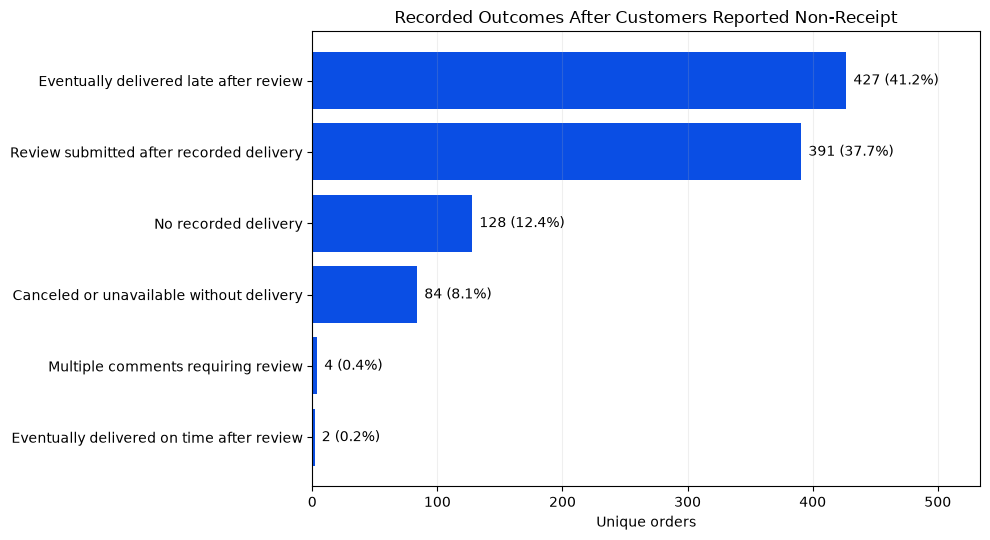

In [108]:
# Visualising recorded outcomes after non-receipt reports
outcome_plot_df = non_receipt_outcome_summary.sort_values(
    "unique_orders"
)
fig, ax = plt.subplots(figsize=(10, 5.5))
bars = ax.barh(
    outcome_plot_df["recorded_outcome"],
    outcome_plot_df["unique_orders"],
    color="#0A4EE4"
)
labels = [
    f"{orders:,} ({share:.1f}%)"
    for orders, share in zip(
        outcome_plot_df["unique_orders"],
        outcome_plot_df["share_pct"]
    )
]

ax.bar_label(bars, labels=labels, padding=5)
ax.set_title("Recorded Outcomes After Customers Reported Non-Receipt")
ax.set_xlabel("Unique orders")
ax.set_ylabel("")
ax.set_xlim(0, outcome_plot_df["unique_orders"].max() * 1.25)
ax.grid(axis="x", alpha=0.2)
plt.tight_layout()
plt.show()

## 10. Interpretation and business handoff

1. **The topic models describe all usable written reviews.** Their frozen
   assignments are tied to the complete order-level review corpus, not a customer
   outcome cohort.
2. **Family volume is not the same as dissatisfaction.** The family overview
   separates how often a subject appears from the proportion receiving 1–2 stars.
3. **The low-score chart prioritises customer-reported themes.** It does not by
   itself prove the operational root cause of each complaint.
4. **Reported non-receipt requires reconciliation.** The audit distinguishes
   eventual late delivery from absent delivery records, failed orders and timing
   inconsistencies.
5. **The operational handoff should be targeted.** Use the exported affected
   order IDs to investigate sellers, routes, states and categories associated
   with confirmed delivery or fulfilment failures.
6. **Coverage is explicit.** Parent and child unassigned groups remain visible
   in coverage reporting and are not assumed to contain no meaningful issues.

## 11. Export analysis-ready outputs

In [102]:
# Preparing the order-level parent-topic export
general_review_export_df = general_review_df.merge(
    general_topic_df[[
        "order_id", "topic_id", "topic_label_en",
        "topic_family_en", "latest_satisfaction_score"
    ]],
    on="order_id", how="left", validate="one_to_one"
)

In [103]:
# Selecting one representative example per named subtopic
handoff_examples_df = (
    subtopic_representatives_df[
        subtopic_representatives_df["subtopic_id"] != -1
    ]
    .sort_values("example_number")
    .drop_duplicates([
        "parent_topic_family", "subtopic_label_en"
    ])
    [[
        "parent_topic_family", "subtopic_label_en",
        "keywords_pt", "review_text_pt", "review_text_en"
    ]]
)

In [104]:
# Preparing the operational subtopic handoff
subtopic_handoff_df = (
    subtopic_count_summary[
        subtopic_count_summary["subtopic_label_en"]
        != "Other / unassigned within family"
    ]
    .merge(
        handoff_examples_df,
        on=["parent_topic_family", "subtopic_label_en"],
        how="left",
        validate="one_to_one"
    )
    .sort_values(
        ["parent_topic_family", "order_count"],
        ascending=[True, False]
    )
    .reset_index(drop=True)
)

display(subtopic_handoff_df)

,parent_topic_family,subtopic_label_en,order_count,share_within_family_pct,keywords_pt,review_text_pt,review_text_en
0,Delivery timing,Delivered on or before expected date,5122,66.831942,"produto, prazo, entregue, entregue prazo, prod...",Produto entregue dentro do prazo.,The product is delivered within the time limit.
1,Delivery timing,Fast delivery with positive feedback,1498,19.545929,"rpida, entrega, entrega rpida, produto, produt...",Ótimo produto entrega super rápida,Great product delivery super fast
2,Delivery timing,Product receipt or mixed delivery feedback,910,11.873695,"produto, recebi, comprei, veio, compra, recebi...",AINDA NAO RECEBI O PRODUTO.,Still don't tell us about the product.
3,Mixed order and fulfilment experience,Non-receipt reported at review time,970,7.669803,"recebi produto, recebi, produto recebi, avalia...",ainda não recebi o produto,I haven't received the product yet
4,Mixed order and fulfilment experience,"Wrong, incompatible or mismatched product",904,7.147940,"pelcula, celular, tela, capa, capinha, pelcula...","não receci a capa do celular, nem o celular",I do not receive cell layer or cell layer
5,Mixed order and fulfilment experience,Late or slow delivery,780,6.167471,"at, prazo, entrega, previso, prazo entrega, da...",Já passou o prazo de entrega e ainda não receb...,It's time for delivery and I haven't received ...
6,Mixed order and fulfilment experience,"Product quality, defect or damage",770,6.088400,"caixa, amassada, embalagem, veio, caixa veio, ...",Embalagem Não veio em uma caixa apenas em uma ...,Packaging Not arrived in a box only in a pack...
7,Mixed order and fulfilment experience,Incomplete order or missing item,660,5.218629,"produtos, comprei produtos, comprei, produtos ...","Bom dia! Comprei dois produtos, mas só recebi um.","Good morning, I bought two products, but I onl..."
8,Mixed order and fulfilment experience,"Cancellation, refund or payment issue",571,4.514905,"dinheiro, volta, dinheiro volta, devolver, rec...",Não recebi o produto e nem meu dinheiro de volta,I didn't get the product and neither my money ...
9,Mixed order and fulfilment experience,Seller/store service or communication,566,4.475370,"loja, lannister, lojas, site, targaryen, conta...",Eu ainda não recebi meu produto tentei entrar ...,I haven't received my product yet I tried to c...


In [105]:
# Saving parent-topic and family-level outputs
parent_topic_catalog_df.to_csv(
    report_output_dir / "parent_topic_catalog.csv", index=False
)
representative_topics_df.to_csv(
    report_output_dir / "parent_topic_examples.csv", index=False
)
topic_family_summary.to_csv(
    report_output_dir / "topic_family_summary.csv", index=False
)
family_selection_audit.to_csv(
    report_output_dir / "family_selection_audit.csv", index=False
)
family_validation_df.to_csv(
    report_output_dir / "selected_family_validation.csv", index=False
)

In [106]:
# Saving order-level and child-topic outputs
general_review_export_df.to_parquet(
    report_output_dir / "review_analysis_ready.parquet", index=False
)
general_subtopic_df.to_parquet(
    report_output_dir / "all_review_subtopic_assignments.parquet",
    index=False
)
subtopic_representatives_df.to_csv(
    report_output_dir / "subtopic_representative_examples.csv",
    index=False
)
subtopic_count_summary.to_csv(
    report_output_dir / "subtopic_count_summary.csv", index=False
)
subtopic_handoff_df.to_csv(
    report_output_dir / "subtopic_operational_handoff.csv", index=False
)

In [107]:
# Saving low-score and non-receipt evidence
negative_subtopic_summary.to_csv(
    report_output_dir / "negative_subtopic_summary.csv", index=False
)
non_receipt_outcome_summary.to_csv(
    report_output_dir / "non_receipt_outcome_summary.csv", index=False
)
non_receipt_audit_df.to_parquet(
    report_output_dir / "non_receipt_order_audit.parquet", index=False
)

print(f"Outputs saved under: {report_output_dir.resolve()}")

Outputs saved under: C:\Users\user\Desktop\olist_analytics\analysis\outputs\review_text_customer_experience
